Pregunta 1

=== DISCRETIZACIÓN DEL ESTANQUE ===
Número de nodos: 11
Volumen total: 1.5708 m3
Masa total de agua: 1570.80 kg
Altura de cada nodo: 0.1818 m
Masa por nodo: 142.80 kg
Capacitancia por nodo: 596902.60 J/K

=== RESULTADOS FINALES ===
ΔH_store final             = -32.260 MJ
ΔH_flow_total final        = -50.185 MJ
ΔH_hl,store final          = -8.378 MJ
Residuo final              = 26.303 MJ


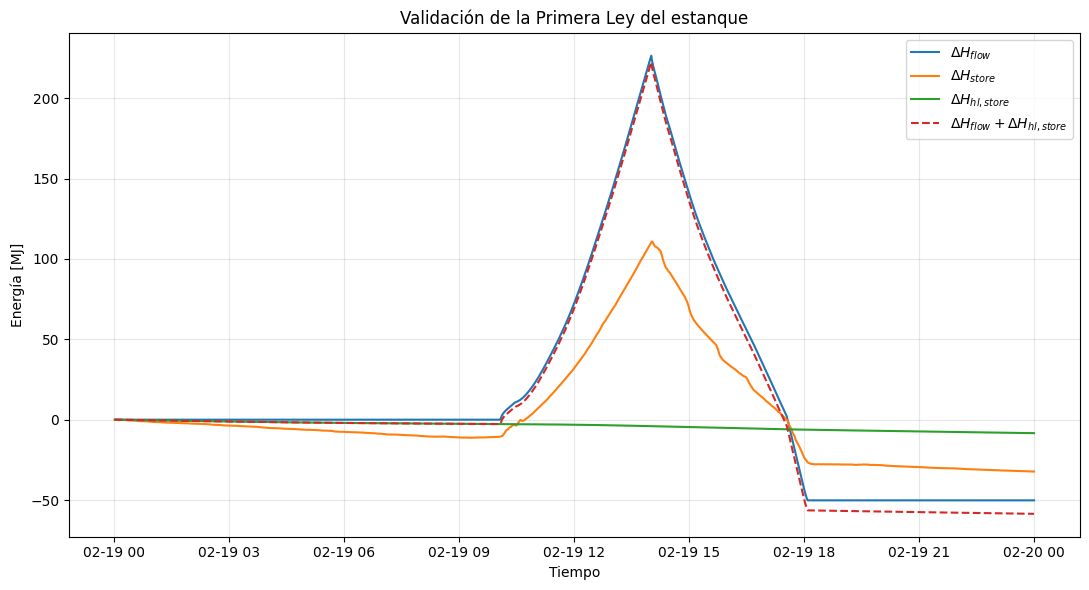

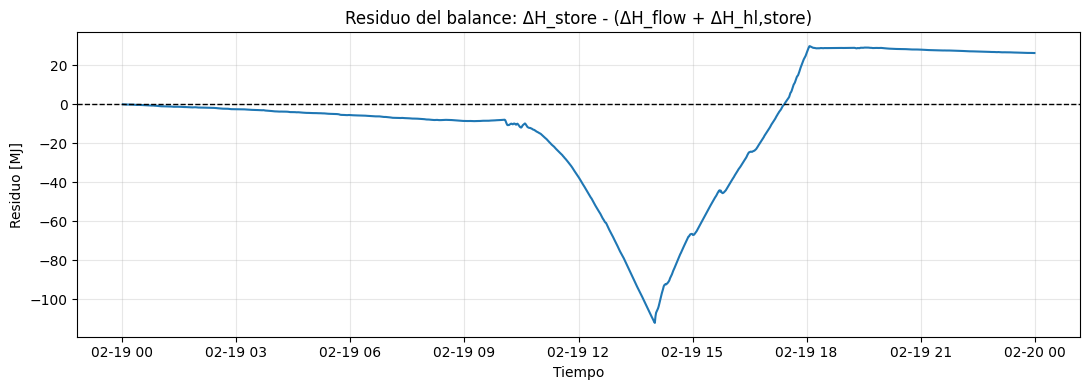

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. CARGAR ARCHIVO Y LIMPIAR BLOQUE TEMPORAL PRINCIPAL

ruta = "datos_estanque_v2.xlsx"
df = pd.read_excel(ruta, sheet_name="Datos")

# Convertir tiempo
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

# Nos quedamos con el día principal continuo del experimento
fecha_base = df["Time"].dt.date.iloc[0]
df = df[df["Time"].dt.date == fecha_base].copy()

# Ordenar por tiempo por seguridad
df = df.sort_values("Time").reset_index(drop=True)

# Delta de tiempo real entre filas
df["dt_s"] = df["Time"].diff().dt.total_seconds()
df["dt_s"] = df["dt_s"].fillna(0)


# 2. PARÁMETROS FÍSICOS DEL ESTANQUE

# Geometría
H = 2.0              # altura [m]
D = 1.0              # diámetro interno [m]
A_sec = np.pi * (D/2)**2
V_total = A_sec * H

# Propiedades del agua
rho = 1000.0         # [kg/m3]
cp = 4180.0          # [J/(kg K)]

# Volumen y masa total de agua
m_total = rho * V_total

# Termocuplas del estanque
TE_cols = [f"TE{i}" for i in range(1, 12)]
M = len(TE_cols)     # número de nodos


# 3. DISCRETIZACIÓN NODAL DEL ESTANQUE

dz = H / M
V_i = A_sec * dz                 # volumen por nodo [m3]
m_i = rho * V_i                  # masa por nodo [kg]
C_i = m_i * cp                   # capacitancia térmica por nodo [J/K]

# Posiciones de centros nodales (útil para más adelante)
z_nodes = np.linspace(dz/2, H - dz/2, M)

print("=== DISCRETIZACIÓN DEL ESTANQUE ===")
print(f"Número de nodos: {M}")
print(f"Volumen total: {V_total:.4f} m3")
print(f"Masa total de agua: {m_total:.2f} kg")
print(f"Altura de cada nodo: {dz:.4f} m")
print(f"Masa por nodo: {m_i:.2f} kg")
print(f"Capacitancia por nodo: {C_i:.2f} J/K")


# 4. VARIACIÓN DE ENERGÍA ACUMULADA EN LOS NODOS

T0_nodes = df.loc[0, TE_cols].copy()

# Cambio nodal respecto del instante inicial
for col in TE_cols:
    df[f"dT_{col}"] = df[col] - T0_nodes[col]

# Energía acumulada total en el estanque [J]
df["dH_store_J"] = 0.0
for col in TE_cols:
    df["dH_store_J"] += m_i * cp * df[f"dT_{col}"]

df["dH_store_MJ"] = df["dH_store_J"] / 1e6


# 5. PÉRDIDAS DE CALOR AL AMBIENTE

k_aisl = 0.040      # conductividad [W/m K]
e_aisl = 0.050      # espesor [m] = 5 cm
U = k_aisl / e_aisl # aproximación simple por conducción dominante [W/m2 K]

# Área lateral por nodo
A_lat_i = np.pi * D * dz

# Tapas
A_tapa = np.pi * (D/2)**2

# Área asignada a cada nodo
A_i = np.full(M, A_lat_i)

# Repartimos tapas:
# nodo superior recibe tapa superior / 2
# nodo inferior recibe tapa inferior / 2
A_i[0] += A_tapa / 2
A_i[-1] += A_tapa / 2

UA_i = U * A_i


# TEMPERATURA AMBIENTE REAL (FEBRERO) explorador solar!

T_amb_horaria = [17, 18, 19, 20, 21, 23, 26, 27, 28, 29, 29, 28,
                 27, 25, 22, 20, 17, 15, 14, 15, 15, 15, 16, 16]

# Hora decimal de cada fila
df["hora_decimal"] = (
    df["Time"].dt.hour +
    df["Time"].dt.minute / 60 +
    df["Time"].dt.second / 3600
)

# Interpolación lineal entre temperaturas horarias
horas_ref = np.arange(24)
df["Tamb_C"] = np.interp(df["hora_decimal"], horas_ref, T_amb_horaria)

# Potencia instantánea de pérdidas [W]
Q_loss_W = np.zeros(len(df))

for i, col in enumerate(TE_cols):
    Q_loss_W += UA_i[i] * (df[col] - df["Tamb_C"])

df["Q_loss_W"] = Q_loss_W

# Energía acumulada perdida al ambiente [J]
# signo negativo porque reduce la energía almacenada
df["dH_hl_store_J"] = -(df["Q_loss_W"] * df["dt_s"]).cumsum()
df["dH_hl_store_MJ"] = df["dH_hl_store_J"] / 1e6


df["P_flow_W"]= cp * (df["F41"] * df["T41"] + df["F51"] * df["T51"] + df["F32"] * df["T36"] - df["F31"] * df["T35"] - df["F51"] * df["T52"])/60
df["dH_flow_J"] = (df["P_flow_W"] * df["dt_s"]).cumsum()
df["dH_flow_MJ"] = df["dH_flow_J"] / 1e6


# 7. VALIDACIÓN DE PRIMERA LEY
#    ΔH_store = ΔH_flow + ΔH_hl,store

df["balance_rhs_J"] = df["dH_flow_J"] + df["dH_hl_store_J"]
df["residuo_J"] = df["dH_store_J"] - df["balance_rhs_J"]

df["balance_rhs_MJ"] = df["balance_rhs_J"] / 1e6
df["residuo_MJ"] = df["residuo_J"] / 1e6

print("\n=== RESULTADOS FINALES ===")
print(f"ΔH_store final             = {df['dH_store_MJ'].iloc[-1]:.3f} MJ")
print(f"ΔH_flow_total final        = {df['dH_flow_MJ'].iloc[-1]:.3f} MJ")
print(f"ΔH_hl,store final          = {df['dH_hl_store_MJ'].iloc[-1]:.3f} MJ")
print(f"Residuo final              = {df['residuo_MJ'].iloc[-1]:.3f} MJ")



# 8. GRÁFICO ESTILO FIG. 4b DEL PAPER

plt.figure(figsize=(11, 6))
plt.plot(df["Time"], df["dH_flow_MJ"], label=r'$\Delta H_{flow}$')
plt.plot(df["Time"], df["dH_store_MJ"], label=r'$\Delta H_{store}$')
plt.plot(df["Time"], df["dH_hl_store_MJ"], label=r'$\Delta H_{hl,store}$')
plt.plot(df["Time"], df["balance_rhs_MJ"], '--', label=r'$\Delta H_{flow} + \Delta H_{hl,store}$')

plt.xlabel("Tiempo")
plt.ylabel("Energía [MJ]")
plt.title("Validación de la Primera Ley del estanque")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 9. GRÁFICO DEL RESIDUO DEL BALANCE

plt.figure(figsize=(11, 4))
plt.plot(df["Time"], df["residuo_MJ"])
plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Tiempo")
plt.ylabel("Residuo [MJ]")
plt.title("Residuo del balance: ΔH_store - (ΔH_flow + ΔH_hl,store)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Pregunta 2


=== RESULTADOS FINALES ENTROPÍA: CASO REAL ===
ΔS_store_exp final      = -103.529 kJ/K
ΔS_flow_exp final       = -172.175 kJ/K
ΔS_hl_store_exp final   = -26.712 kJ/K
ΔS_irr_int_exp final    = 95.357 kJ/K


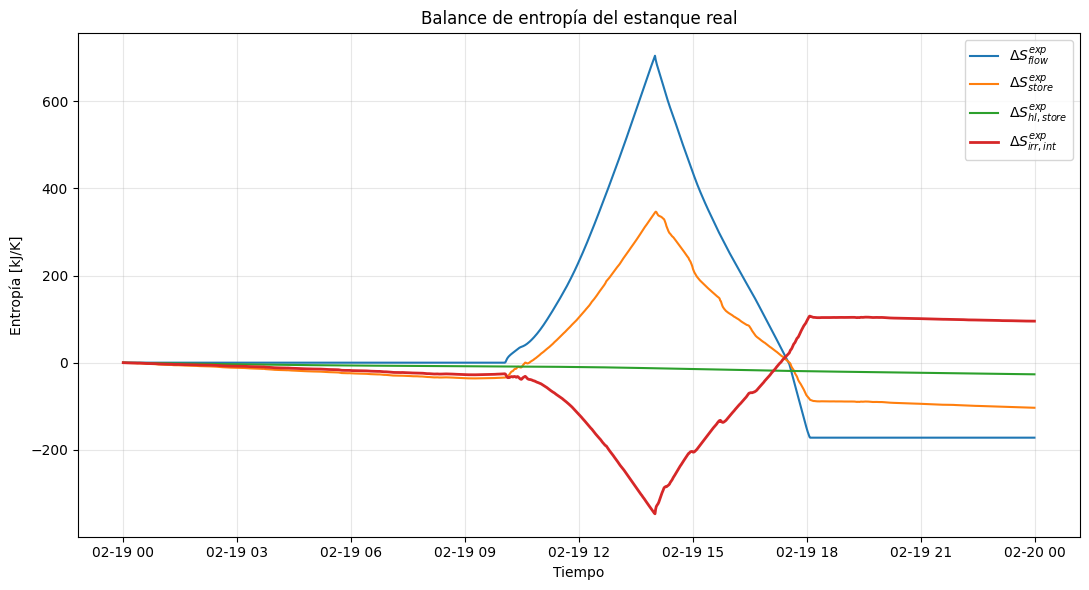

In [32]:
#10. PARTE 2a) BALANCE DE ENTROPÍA - CASO REAL


def s_liq(T_C):
    #Retorna s(T) relativa a T_ref = 273.15 K
    #[J/(kg K)]
    T_K = T_C + 273.15
    return cp * np.log(T_K / 273.15)



# 10.1 CAMBIO DE ENTROPÍA ALMACENADA EN EL ESTANQUE

df["dS_store_JK"] = 0.0

for col in TE_cols:
    df["dS_store_JK"] += m_i * (s_liq(df[col]) - s_liq(T0_nodes[col]))

df["dS_store_kJK"] = df["dS_store_JK"] / 1e3



# 10.2 CAMBIO DE ENTROPÍA POR FLUJO MÁSICO

df["Sdot_flow_WK"] = (df["F41"] * s_liq(df["T41"]) + df["F51"] * s_liq(df["T51"]) + df["F32"] * s_liq(df["T36"]) - df["F31"] * s_liq(df["T35"]) - df["F51"] * s_liq(df["T52"])) / 60.0   # L/min ~ kg/min -> /60 => kg/s

df["dS_flow_JK"] = (df["Sdot_flow_WK"] * df["dt_s"]).cumsum()
df["dS_flow_kJK"] = df["dS_flow_JK"] / 1e3



# 10.3 CAMBIO DE ENTROPÍA POR PÉRDIDAS DE CALOR AL AMBIENTE

S_loss_WK = np.zeros(len(df))

for i, col in enumerate(TE_cols):
    T_node_K = df[col] + 273.15
    S_loss_WK += UA_i[i] * (df[col] - df["Tamb_C"]) / T_node_K

# negativo porque es entropía que abandona el tanque hacia el ambiente
df["dS_hl_store_JK"] = -(S_loss_WK * df["dt_s"]).cumsum()
df["dS_hl_store_kJK"] = df["dS_hl_store_JK"] / 1e3



# 10.4 GENERACIÓN INTERNA DE ENTROPÍA ACUMULADA

df["dS_irr_int_exp_JK"] = (
    df["dS_store_JK"]
    - df["dS_flow_JK"]
    - df["dS_hl_store_JK"]
)

df["dS_irr_int_exp_kJK"] = df["dS_irr_int_exp_JK"] / 1e3



# 11. RESULTADOS FINALES - CASO REAL

print("\n=== RESULTADOS FINALES ENTROPÍA: CASO REAL ===")
print(f"ΔS_store_exp final      = {df['dS_store_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_flow_exp final       = {df['dS_flow_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_hl_store_exp final   = {df['dS_hl_store_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_irr_int_exp final    = {df['dS_irr_int_exp_kJK'].iloc[-1]:.3f} kJ/K")



# 12. GRÁFICO DE BALANCE DE ENTROPÍA - CASO REAL


plt.figure(figsize=(11, 6))
plt.plot(df["Time"], df["dS_flow_kJK"], label=r'$\Delta S_{flow}^{exp}$')
plt.plot(df["Time"], df["dS_store_kJK"], label=r'$\Delta S_{store}^{exp}$')
plt.plot(df["Time"], df["dS_hl_store_kJK"], label=r'$\Delta S_{hl,store}^{exp}$')
plt.plot(df["Time"], df["dS_irr_int_exp_kJK"], label=r'$\Delta S_{irr,int}^{exp}$', linewidth=2)

plt.xlabel("Tiempo")
plt.ylabel("Entropía [kJ/K]")
plt.title("Balance de entropía del estanque real")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



=== RESULTADOS FINALES ENTROPÍA: ESTANQUE MIXTO ===
Tmix inicial               = 37.664 °C
ΔS_store_mix final         = -89.042 kJ/K
ΔS_flow_mix final          = -77.867 kJ/K
ΔS_hl_store_mix final      = -27.726 kJ/K
ΔS_irr_int_mix final       = 16.550 kJ/K
ΔS_mix_init opcional       = 1.120 kJ/K
ΔS_irr_int_mix corr final  = 17.671 kJ/K


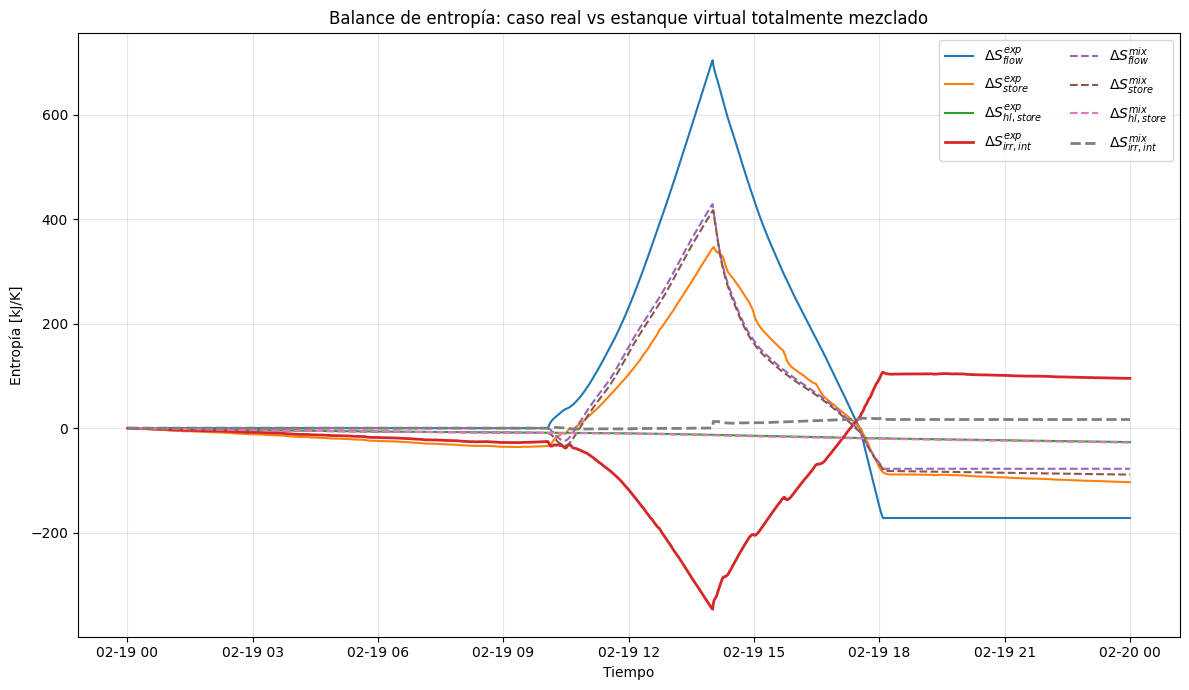

In [ ]:
# 13.1 PARÁMETROS DEL ESTANQUE MIXTO

UA_total = np.sum(UA_i)   # mismo aislamiento total que el caso real

# Temperatura inicial del estanque virtual:
# promedio másico del perfil inicial real
Tmix0_C = np.mean([T0_nodes[col] for col in TE_cols])

df["Tmix_C"] = np.nan
df.loc[0, "Tmix_C"] = Tmix0_C


# 13.2 DEFINIR FLUJOS DE ENTRADA / SALIDA

def P_in_mix_W(row):
    return cp * (
        row["F41"] * row["T41"] +
        row["F51"] * row["T51"] +
        row["F32"] * row["T36"]
    ) / 60.0

def m_out_mix_kg_s(row):
    return (row["F31"] + row["F51"]) / 60.0


# 13.3 SIMULACIÓN DE Tmix(t) POR BALANCE DE ENERGÍA

for k in range(1, len(df)):
    row_prev = df.iloc[k - 1]

    dt = row_prev["dt_s"]
    Tmix_prev = df.loc[k - 1, "Tmix_C"]
    Tamb_prev = row_prev["Tamb_C"]

    Pin = P_in_mix_W(row_prev)
    Pout = m_out_mix_kg_s(row_prev) * cp * Tmix_prev
    Qloss = UA_total * (Tmix_prev - Tamb_prev)

    dTmix = (Pin - Pout - Qloss) * dt / (m_total * cp)

    df.loc[k, "Tmix_C"] = Tmix_prev + dTmix

# 13.4 CAMBIO DE ENTROPÍA ALMACENADA EN EL ESTANQUE MIXTO

df["dS_store_mix_JK"] = m_total * (s_liq(df["Tmix_C"]) - s_liq(Tmix0_C))
df["dS_store_mix_kJK"] = df["dS_store_mix_JK"] / 1e3


# 13.5 CAMBIO DE ENTROPÍA POR FLUJO MÁSICO EN EL MIXTO

df["Sdot_flow_mix_WK"] = (
    df["F41"] * s_liq(df["T41"]) +
    df["F51"] * s_liq(df["T51"]) +
    df["F32"] * s_liq(df["T36"]) -
    df["F31"] * s_liq(df["Tmix_C"]) -
    df["F51"] * s_liq(df["Tmix_C"])
) / 60.0

df["dS_flow_mix_JK"] = (df["Sdot_flow_mix_WK"] * df["dt_s"]).cumsum()
df["dS_flow_mix_kJK"] = df["dS_flow_mix_JK"] / 1e3


# 13.6 CAMBIO DE ENTROPÍA POR PÉRDIDAS DE CALOR
#     EN EL ESTANQUE MIXTO

Tmix_K = df["Tmix_C"] + 273.15

df["Sdot_hl_mix_WK"] = -UA_total * (df["Tmix_C"] - df["Tamb_C"]) / Tmix_K
df["dS_hl_store_mix_JK"] = (df["Sdot_hl_mix_WK"] * df["dt_s"]).cumsum()
df["dS_hl_store_mix_kJK"] = df["dS_hl_store_mix_JK"] / 1e3


# 13.7 GENERACIÓN INTERNA DE ENTROPÍA ACUMULADA

df["dS_irr_int_mix_JK"] = (
    df["dS_store_mix_JK"]
    - df["dS_flow_mix_JK"]
    - df["dS_hl_store_mix_JK"]
)


# 13.8 CORRECCIÓN OPCIONAL:
#     ENTROPÍA DE MEZCLA INSTANTÁNEA INICIAL

S0_real_JK = sum(m_i * s_liq(T0_nodes[col]) for col in TE_cols)
S0_mix_JK  = m_total * s_liq(Tmix0_C)

dS_mix_init_JK = S0_mix_JK - S0_real_JK

df["dS_irr_int_mix_corr_JK"] = df["dS_irr_int_mix_JK"] + dS_mix_init_JK
df["dS_irr_int_mix_corr_kJK"] = df["dS_irr_int_mix_corr_JK"] / 1e3

df["dS_irr_int_mix_kJK"] = df["dS_irr_int_mix_JK"] / 1e3


# 13.9 RESULTADOS FINALES


print("\n=== RESULTADOS FINALES ENTROPÍA: ESTANQUE MIXTO ===")
print(f"Tmix inicial               = {Tmix0_C:.3f} °C")
print(f"ΔS_store_mix final         = {df['dS_store_mix_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_flow_mix final          = {df['dS_flow_mix_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_hl_store_mix final      = {df['dS_hl_store_mix_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_irr_int_mix final       = {df['dS_irr_int_mix_kJK'].iloc[-1]:.3f} kJ/K")
print(f"ΔS_mix_init opcional       = {dS_mix_init_JK/1e3:.3f} kJ/K")
print(f"ΔS_irr_int_mix corr final  = {df['dS_irr_int_mix_corr_kJK'].iloc[-1]:.3f} kJ/K")


# 14. GRÁFICO ENTROPÍA - REAL vs MIXTO

plt.figure(figsize=(12, 7))

# Caso real
plt.plot(df["Time"], df["dS_flow_kJK"], label=r'$\Delta S_{flow}^{exp}$')
plt.plot(df["Time"], df["dS_store_kJK"], label=r'$\Delta S_{store}^{exp}$')
plt.plot(df["Time"], df["dS_hl_store_kJK"], label=r'$\Delta S_{hl,store}^{exp}$')
plt.plot(df["Time"], df["dS_irr_int_exp_kJK"], linewidth=2,
         label=r'$\Delta S_{irr,int}^{exp}$')

# Caso mixto
plt.plot(df["Time"], df["dS_flow_mix_kJK"], '--', label=r'$\Delta S_{flow}^{mix}$')
plt.plot(df["Time"], df["dS_store_mix_kJK"], '--', label=r'$\Delta S_{store}^{mix}$')
plt.plot(df["Time"], df["dS_hl_store_mix_kJK"], '--', label=r'$\Delta S_{hl,store}^{mix}$')
plt.plot(df["Time"], df["dS_irr_int_mix_kJK"], '--', linewidth=2,
         label=r'$\Delta S_{irr,int}^{mix}$')

plt.xlabel("Tiempo")
plt.ylabel("Entropía [kJ/K]")
plt.title("Balance de entropía: caso real vs estanque virtual totalmente mezclado")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Parte 3

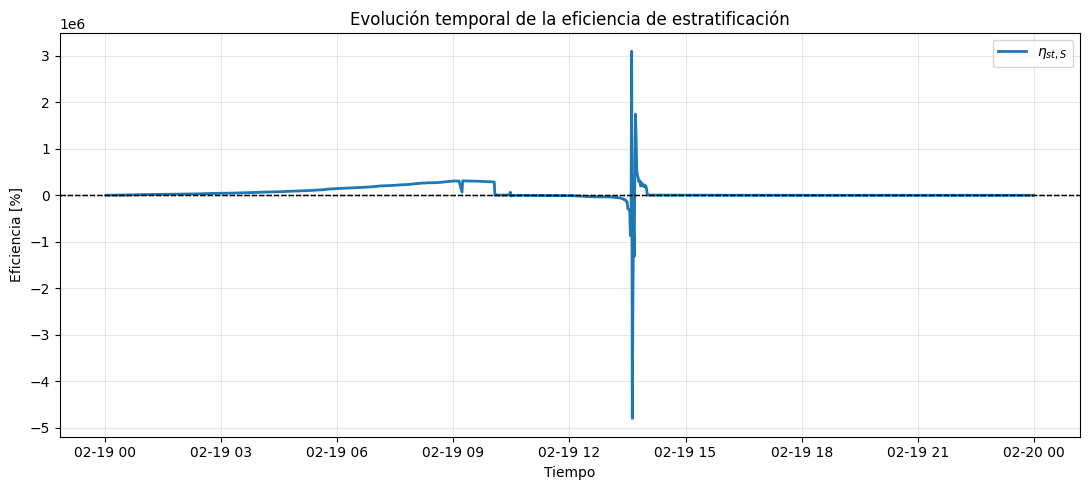

In [42]:
eps = 1e-9

df["eta_st_S"] = np.where(
    np.abs(df["dS_irr_int_mix_JK"]) > eps,
    1 - df["dS_irr_int_exp_JK"] / df["dS_irr_int_mix_JK"],
    np.nan
)

df["eta_st_S_pct"] = 100 * df["eta_st_S"]

plt.figure(figsize=(11,5))
plt.plot(df["Time"], df["eta_st_S_pct"], linewidth=2, label=r'$\eta_{st,S}$')

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.axhline(100, color="k", linestyle=":", linewidth=1)

plt.xlabel("Tiempo")
plt.ylabel("Eficiencia [%]")
plt.title("Evolución temporal de la eficiencia de estratificación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

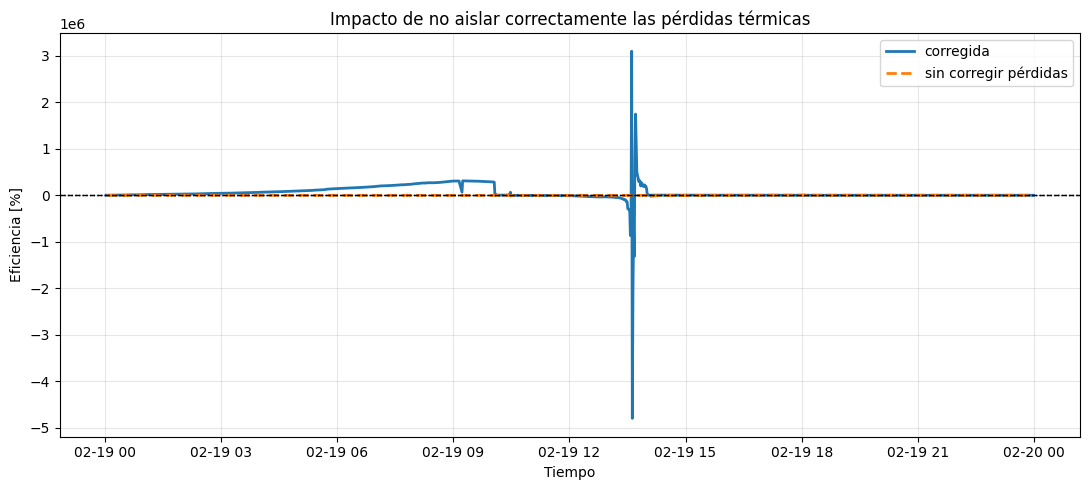

In [43]:
num0 = df["dS_store_JK"] - df["dS_flow_JK"]
den0 = df["dS_store_mix_JK"] - df["dS_flow_mix_JK"]

df["eta_st_S0"] = np.where(
    np.abs(den0) > eps,
    1 - num0 / den0,
    np.nan
)

df["eta_st_S0_pct"] = 100 * df["eta_st_S0"]

plt.figure(figsize=(11,5))
plt.plot(df["Time"], df["eta_st_S_pct"], label="corregida", linewidth=2)
plt.plot(df["Time"], df["eta_st_S0_pct"], "--", label="sin corregir pérdidas", linewidth=2)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.axhline(100, color="k", linestyle=":", linewidth=1)

plt.xlabel("Tiempo")
plt.ylabel("Eficiencia [%]")
plt.title("Impacto de no aislar correctamente las pérdidas térmicas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

       Escenario  factor_U  U [W/m2K]  UA_total [W/K]  Q_loss_max [W]  \
0  Aislado ideal       0.0        0.0           0.000           0.000   
1     0.5 U_base       0.5        0.4           2.827          89.747   
2         U_base       1.0        0.8           5.655         179.494   
3       2 U_base       2.0        1.6          11.310         358.988   
4       5 U_base       5.0        4.0          28.274         897.470   

   Q_loss_prom [W]  ΔH_hl,final [MJ]  ΔS_hl,final [kJ/K]  
0            0.000            -0.000              -0.000  
1           48.588            -4.189             -13.356  
2           97.175            -8.378             -26.712  
3          194.351           -16.756             -53.424  
4          485.877           -41.889            -133.559  


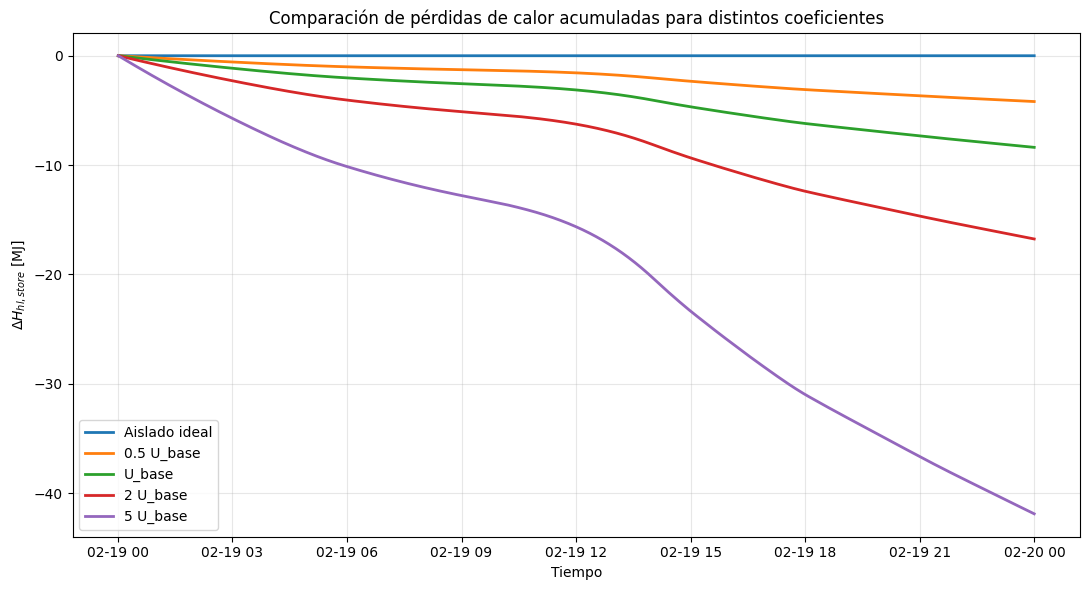

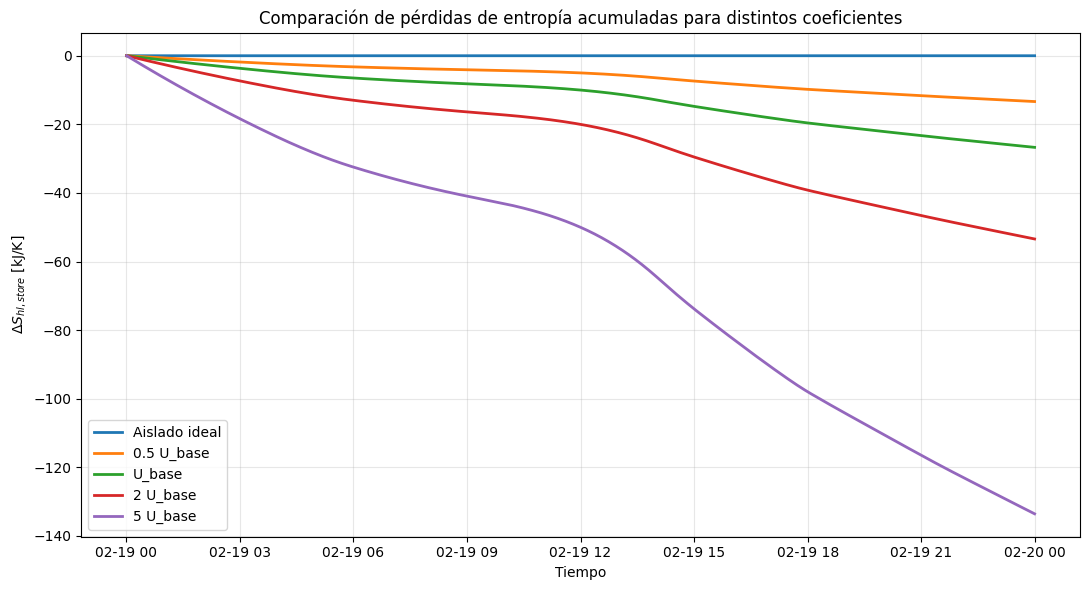

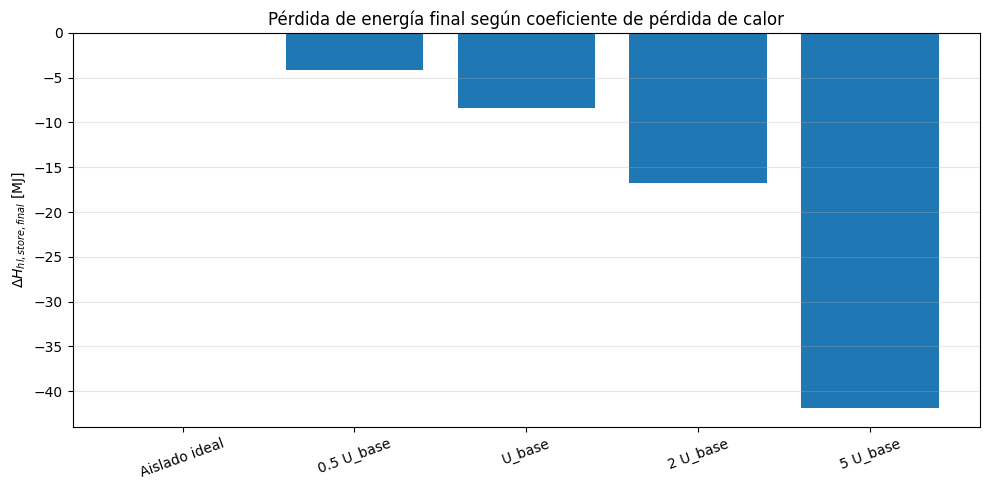

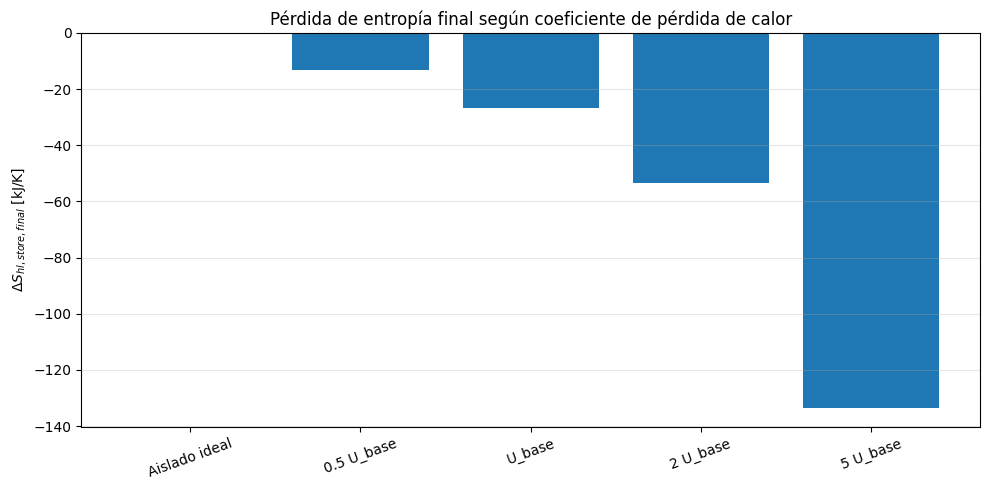

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

escenarios = {
    "Aislado ideal": 0.0,
    "0.5 U_base": 0.5,
    "U_base": 1.0,
    "2 U_base": 2.0,
    "5 U_base": 5.0,
}

def calcular_perdidas_para_factor_UA(df, TE_cols, A_i, U_base, factor):
    U_test = U_base * factor
    UA_i_test = U_test * A_i
    UA_tot_test = UA_i_test.sum()

    # ----- Pérdidas de energía -----
    Q_loss_W = np.zeros(len(df))
    for i, col in enumerate(TE_cols):
        Q_loss_W += UA_i_test[i] * (df[col] - df["Tamb_C"])

    dH_hl_store_J = -(Q_loss_W * df["dt_s"]).cumsum()
    dH_hl_store_MJ = dH_hl_store_J / 1e6

    # ----- Pérdidas de entropía -----
    S_loss_WK = np.zeros(len(df))
    for i, col in enumerate(TE_cols):
        Tnode_K = df[col] + 273.15
        S_loss_WK += UA_i_test[i] * (df[col] - df["Tamb_C"]) / Tnode_K

    dS_hl_store_JK = -(S_loss_WK * df["dt_s"]).cumsum()
    dS_hl_store_kJK = dS_hl_store_JK / 1e3

    return {
        "U_test": U_test,
        "UA_tot_test": UA_tot_test,
        "Q_loss_W": Q_loss_W,
        "dH_hl_store_J": dH_hl_store_J,
        "dH_hl_store_MJ": dH_hl_store_MJ,
        "dS_hl_store_JK": dS_hl_store_JK,
        "dS_hl_store_kJK": dS_hl_store_kJK,
    }


resultados_UA = {}
resumen = []

for nombre, factor in escenarios.items():
    res = calcular_perdidas_para_factor_UA(df, TE_cols, A_i, U, factor)
    resultados_UA[nombre] = res

    resumen.append({
        "Escenario": nombre,
        "factor_U": factor,
        "U [W/m2K]": res["U_test"],
        "UA_total [W/K]": res["UA_tot_test"],
        "Q_loss_max [W]": np.max(res["Q_loss_W"]),
        "Q_loss_prom [W]": np.mean(res["Q_loss_W"]),
        "ΔH_hl,final [MJ]": res["dH_hl_store_MJ"].iloc[-1],
        "ΔS_hl,final [kJ/K]": res["dS_hl_store_kJK"].iloc[-1],
    })

df_resumen_UA = pd.DataFrame(resumen)
print(df_resumen_UA.round(3))


plt.figure(figsize=(11, 6))
for nombre, res in resultados_UA.items():
    plt.plot(df["Time"], res["dH_hl_store_MJ"], label=nombre, linewidth=2)

plt.xlabel("Tiempo")
plt.ylabel(r'$\Delta H_{hl,store}$ [MJ]')
plt.title("Comparación de pérdidas de calor acumuladas para distintos coeficientes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(11, 6))
for nombre, res in resultados_UA.items():
    plt.plot(df["Time"], res["dS_hl_store_kJK"], label=nombre, linewidth=2)

plt.xlabel("Tiempo")
plt.ylabel(r'$\Delta S_{hl,store}$ [kJ/K]')
plt.title("Comparación de pérdidas de entropía acumuladas para distintos coeficientes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.bar(df_resumen_UA["Escenario"], df_resumen_UA["ΔH_hl,final [MJ]"])
plt.ylabel(r'$\Delta H_{hl,store,final}$ [MJ]')
plt.title("Pérdida de energía final según coeficiente de pérdida de calor")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.bar(df_resumen_UA["Escenario"], df_resumen_UA["ΔS_hl,final [kJ/K]"])
plt.ylabel(r'$\Delta S_{hl,store,final}$ [kJ/K]')
plt.title("Pérdida de entropía final según coeficiente de pérdida de calor")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()